# 지하철 승하차 인원 예측 프로젝트

## 2. 데이터 불러오기

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 시각화 한글 깨짐 방지
plt.rc('font', family='Malgun Gothic')
mpl.rcParams['axes.unicode_minus'] = False

# 출력 데이터 정렬 가독성 좋게
pd.set_option('display.width', 200)

df = pd.read_csv("data/subway.csv", encoding="cp949")
df.head()

,사용월,호선명,지하철역,04시-05시 승차인원,04시-05시 하차인원,05시-06시 승차인원,05시-06시 하차인원,06시-07시 승차인원,06시-07시 하차인원,07시-08시 승차인원,...,23시-24시 하차인원,00시-01시 승차인원,00시-01시 하차인원,01시-02시 승차인원,01시-02시 하차인원,02시-03시 승차인원,02시-03시 하차인원,03시-04시 승차인원,03시-04시 하차인원,작업일자
0,202608,1호선,동대문,378,22,8757,1674,8493,5926,13469,...,11231,884,2788,1,295,0,0,0,0,20260903
1,202608,1호선,동묘앞,131,1,2909,994,4035,5306,8582,...,5117,117,2396,0,283,0,0,0,0,20260903
2,202608,1호선,서울역,721,43,11681,12424,38109,66108,108569,...,36054,4387,7926,11,168,0,0,0,0,20260903
3,202608,1호선,시청,43,1,1983,5453,3975,29679,7603,...,4203,563,844,1,11,0,0,0,0,20260903
4,202608,1호선,신설동,285,10,8398,2144,10483,9129,22040,...,10037,350,2774,0,0,0,0,0,0,20260903


## 3. 데이터 기본 정보 확인

In [28]:
print("처음 데이터 크기:", df.shape)

처음 데이터 크기: (84838, 52)


In [29]:
print("데이터 상세정보:\n")
df.info()

데이터 상세정보:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84838 entries, 0 to 84837
Data columns (total 52 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   사용월           84838 non-null  int64 
 1   호선명           84838 non-null  object
 2   지하철역          84838 non-null  object
 3   04시-05시 승차인원  84838 non-null  int64 
 4   04시-05시 하차인원  84838 non-null  int64 
 5   05시-06시 승차인원  84838 non-null  int64 
 6   05시-06시 하차인원  84838 non-null  int64 
 7   06시-07시 승차인원  84838 non-null  int64 
 8   06시-07시 하차인원  84838 non-null  int64 
 9   07시-08시 승차인원  84838 non-null  int64 
 10  07시-08시 하차인원  84838 non-null  int64 
 11  08시-09시 승차인원  84838 non-null  int64 
 12  08시-09시 하차인원  84838 non-null  int64 
 13  09시-10시 승차인원  84838 non-null  int64 
 14  09시-10시 하차인원  84838 non-null  int64 
 15  10시-11시 승차인원  84838 non-null  int64 
 16  10시-11시 하차인원  84838 non-null  int64 
 17  11시-12시 승차인원  84838 non-null  int64 
 18  11시-12시 하차인원  84838 non-null  int64

In [30]:
df.columns

Index(['사용월', '호선명', '지하철역', '04시-05시 승차인원', '04시-05시 하차인원', '05시-06시 승차인원', '05시-06시 하차인원', '06시-07시 승차인원', '06시-07시 하차인원', '07시-08시 승차인원', '07시-08시 하차인원', '08시-09시 승차인원', '08시-09시 하차인원',
       '09시-10시 승차인원', '09시-10시 하차인원', '10시-11시 승차인원', '10시-11시 하차인원', '11시-12시 승차인원', '11시-12시 하차인원', '12시-13시 승차인원', '12시-13시 하차인원', '13시-14시 승차인원', '13시-14시 하차인원', '14시-15시 승차인원', '14시-15시 하차인원',
       '15시-16시 승차인원', '15시-16시 하차인원', '16시-17시 승차인원', '16시-17시 하차인원', '17시-18시 승차인원', '17시-18시 하차인원', '18시-19시 승차인원', '18시-19시 하차인원', '19시-20시 승차인원', '19시-20시 하차인원', '20시-21시 승차인원', '20시-21시 하차인원',
       '21시-22시 승차인원', '21시-22시 하차인원', '22시-23시 승차인원', '22시-23시 하차인원', '23시-24시 승차인원', '23시-24시 하차인원', '00시-01시 승차인원', '00시-01시 하차인원', '01시-02시 승차인원', '01시-02시 하차인원', '02시-03시 승차인원', '02시-03시 하차인원',
       '03시-04시 승차인원', '03시-04시 하차인원', '작업일자'],
      dtype='object')

### 데이터의 실제 범위 확인

In [31]:
print("사용월:", df["사용월"].unique())          # 어떤 월이 있는지 확인
print()
print("개월 수:", df["사용월"].nunique())          # 몇 개월인지 확인
print()
print("호선:", df["호선명"].unique())               # 어떤 호선이 있는지
print()
print("호선 수:", df["호선명"].nunique())            # 호선이 몇 종류인지
print()
print("역 개수:", df["지하철역"].nunique())           # 역이 몇 종류인지
print()
print("중복 행:", df.duplicated(subset=["사용월", "호선명", "지하철역"]).sum())

사용월: [202608 202607 202606 202605 202604 202603 202602 202601 202512 202511
 202510 202509 202508 202507 202506 202505 202504 202503 202502 202501
 202412 202411 202410 202409 202408 202407 202406 202405 202404 202403
 202402 202401 202312 202311 202310 202309 202308 202307 202306 202305
 202304 202303 202302 202301 202212 202211 202210 202209 202208 202207
 202206 202205 202204 202203 202202 202201 202112 202111 202110 202109
 202108 202107 202106 202105 202104 202103 202102 202101 202012 202011
 202010 202009 202008 202007 202006 202005 202004 202003 202002 202001
 201912 201911 201910 201909 201908 201907 201906 201905 201904 201903
 201902 201901 201812 201811 201810 201809 201808 201807 201806 201805
 201804 201803 201802 201801 201712 201711 201710 201709 201708 201707
 201706 201705 201704 201703 201702 201701 201612 201611 201610 201609
 201608 201607 201606 201605 201604 201603 201602 201601 201512 201511
 201510 201509 201508 201507 201506 201505 201504 201503 201502 201501]


## 4. 중복 데이터 확인 및 제거

In [32]:
duplicate = df[df.duplicated(subset=["사용월", "호선명", "지하철역"], keep=False)]
duplicate.head(10)

,사용월,호선명,지하철역,04시-05시 승차인원,04시-05시 하차인원,05시-06시 승차인원,05시-06시 하차인원,06시-07시 승차인원,06시-07시 하차인원,07시-08시 승차인원,...,23시-24시 하차인원,00시-01시 승차인원,00시-01시 하차인원,01시-02시 승차인원,01시-02시 하차인원,02시-03시 승차인원,02시-03시 하차인원,03시-04시 승차인원,03시-04시 하차인원,작업일자
623,202607,1호선,동대문,661,30,10690,2075,9128,7110,14985,...,11075,1044,3223,1,311,0,0,0,0,20260803
624,202607,1호선,동대문,661,30,10690,2075,9128,7110,14985,...,11075,1044,3223,1,311,0,0,0,0,20260803
625,202607,1호선,동묘앞,132,3,3235,1031,4208,5471,9288,...,5071,162,2346,0,317,0,0,0,0,20260803
626,202607,1호선,동묘앞,132,3,3235,1031,4208,5471,9288,...,5071,162,2346,0,317,0,0,0,0,20260803
627,202607,1호선,서울역,671,50,11781,12529,39125,65359,116841,...,36173,4509,7903,22,241,0,0,0,0,20260803
628,202607,1호선,서울역,671,50,11781,12529,39125,65359,116841,...,36173,4509,7903,22,241,0,0,0,0,20260803
629,202607,1호선,시청,97,1,1860,6089,3946,31458,7701,...,3740,580,948,0,15,0,0,0,0,20260803
630,202607,1호선,시청,97,1,1860,6089,3946,31458,7701,...,3740,580,948,0,15,0,0,0,0,20260803
631,202607,1호선,신설동,346,9,9141,2253,11241,9817,23652,...,9764,459,2886,0,1,0,0,0,0,20260803
632,202607,1호선,신설동,346,9,9141,2253,11241,9817,23652,...,9764,459,2886,0,1,0,0,0,0,20260803


In [ ]:
# 모든 컬럼의 값이 완전히 똑같은 중복 행의 개수 확인
df.duplicated().sum()

np.int64(1241)

In [34]:
# 완전히 동일한 중복 행 제거
df = df.drop_duplicates()

# 제거 후 데이터 크기 확인
print("중복 제거 후 데이터 크기:", df.shape)

중복 제거 후 데이터 크기: (83597, 52)


In [35]:
# 같은 월 + 호선 + 역인데 값이 다른 데이터가 남아있는지 재확인
duplicate = df[df.duplicated(subset=["사용월", "호선명", "지하철역"], keep=False)]
duplicate.head(20)

,사용월,호선명,지하철역,04시-05시 승차인원,04시-05시 하차인원,05시-06시 승차인원,05시-06시 하차인원,06시-07시 승차인원,06시-07시 하차인원,07시-08시 승차인원,...,23시-24시 하차인원,00시-01시 승차인원,00시-01시 하차인원,01시-02시 승차인원,01시-02시 하차인원,02시-03시 승차인원,02시-03시 하차인원,03시-04시 승차인원,03시-04시 하차인원,작업일자
47154,202006,경의선,디지털미디어시티,1,0,993,535,2545,1538,8844,...,2036,53,459,0,0,0,0,0,0,20200703
47155,202006,경의선,디지털미디어시티,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,20200703
47159,202006,경의선,서울역,11,6,910,33,934,6593,2371,...,1073,1,86,0,0,0,0,0,0,20200703
47160,202006,경의선,서울역,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,20200703
47172,202006,경의선,홍대입구,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,20200703
47173,202006,경의선,홍대입구,3,0,391,78,687,725,1411,...,1009,148,389,0,0,0,0,0,0,20200703
47757,202005,경의선,서울역,4,2,810,15,883,5312,1901,...,1101,3,128,0,0,0,0,0,0,20200603
47758,202005,경의선,서울역,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,20200603
48355,202004,경의선,서울역,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,20200503
48356,202004,경의선,서울역,2,1,699,6,722,4722,1722,...,876,0,73,0,0,0,0,0,0,20200503


In [36]:
# 남은 중복 데이터 중 승차인원이 모두 0인 행 확인
duplicate[duplicate.filter(like="승차인원").sum(axis=1) == 0]

,사용월,호선명,지하철역,04시-05시 승차인원,04시-05시 하차인원,05시-06시 승차인원,05시-06시 하차인원,06시-07시 승차인원,06시-07시 하차인원,07시-08시 승차인원,...,23시-24시 하차인원,00시-01시 승차인원,00시-01시 하차인원,01시-02시 승차인원,01시-02시 하차인원,02시-03시 승차인원,02시-03시 하차인원,03시-04시 승차인원,03시-04시 하차인원,작업일자


## 5. EDA
"이 데이터가 실제로 어떻게 생겼는지 그래프와 통계로 살펴보는 단계"

In [37]:
# 시간대별 승차인원 컬럼만 선택
boarding_cols = [col for col in df.columns if "승차인원" in col]

# 시간대별 전체 승차인원 합계
boarding_sum = df[boarding_cols].sum()
boarding_sum

04시-05시 승차인원      17773272
05시-06시 승차인원     431948622
06시-07시 승차인원     890295260
07시-08시 승차인원    2257517402
08시-09시 승차인원    2567125734
09시-10시 승차인원    1622825681
10시-11시 승차인원    1244934727
11시-12시 승차인원    1254907585
12시-13시 승차인원    1367385757
13시-14시 승차인원    1419680144
14시-15시 승차인원    1415072563
15시-16시 승차인원    1571979871
16시-17시 승차인원    1815829993
17시-18시 승차인원    2296025116
18시-19시 승차인원    2936447489
19시-20시 승차인원    1673353859
20시-21시 승차인원    1318364655
21시-22시 승차인원    1242194079
22시-23시 승차인원     999025179
23시-24시 승차인원     422538703
00시-01시 승차인원      51467131
01시-02시 승차인원        271621
02시-03시 승차인원         17672
03시-04시 승차인원          1038
dtype: int64

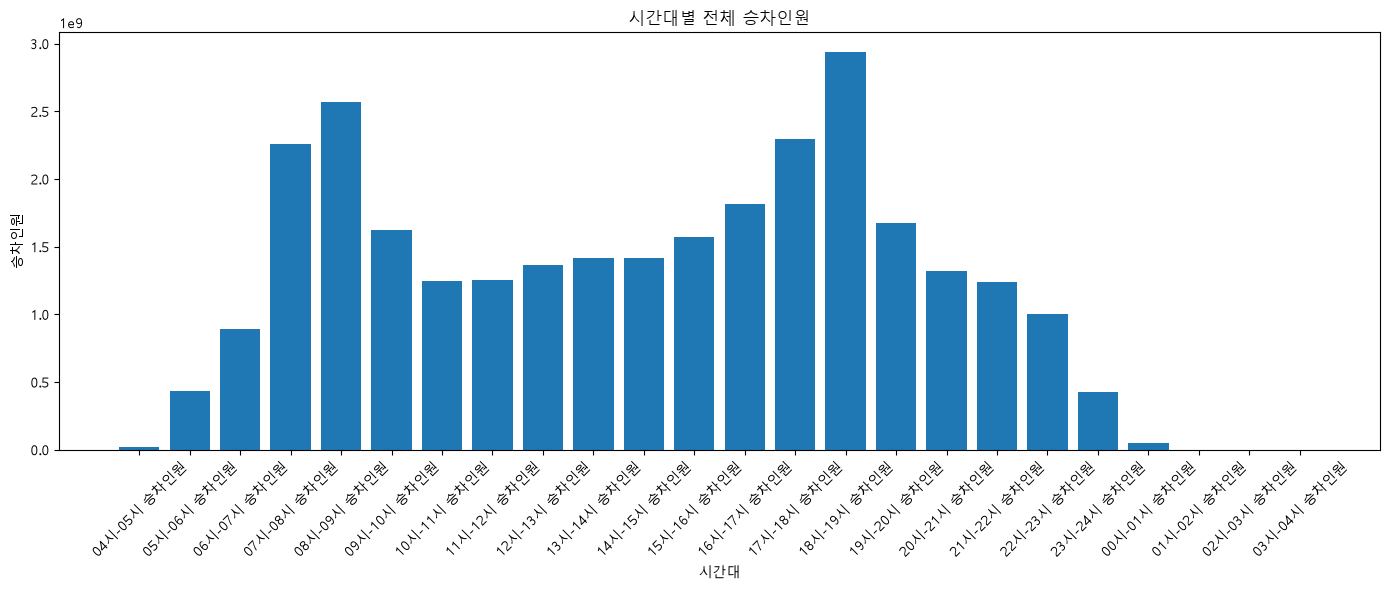

In [38]:
# 시간대별 승차인원 그래프 시각화
plt.figure(figsize=(14, 6))
plt.bar(boarding_sum.index, boarding_sum.values)
plt.title("시간대별 전체 승차인원")
plt.xlabel("시간대")
plt.ylabel("승차인원")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [39]:
# 역별 승차인원 비교
station_sum = df.groupby("지하철역")[boarding_cols].sum()
station_total = station_sum.sum(axis=1)
station_total = station_total.sort_values(ascending=False)
station_total.head(10)

지하철역
서울역         368573941
강남          361660917
고속터미널       357769099
홍대입구        348332550
잠실(송파구청)    330919465
사당          280806439
신림          264183848
선릉          258280869
구로디지털단지     240351947
신도림         238156550
dtype: int64

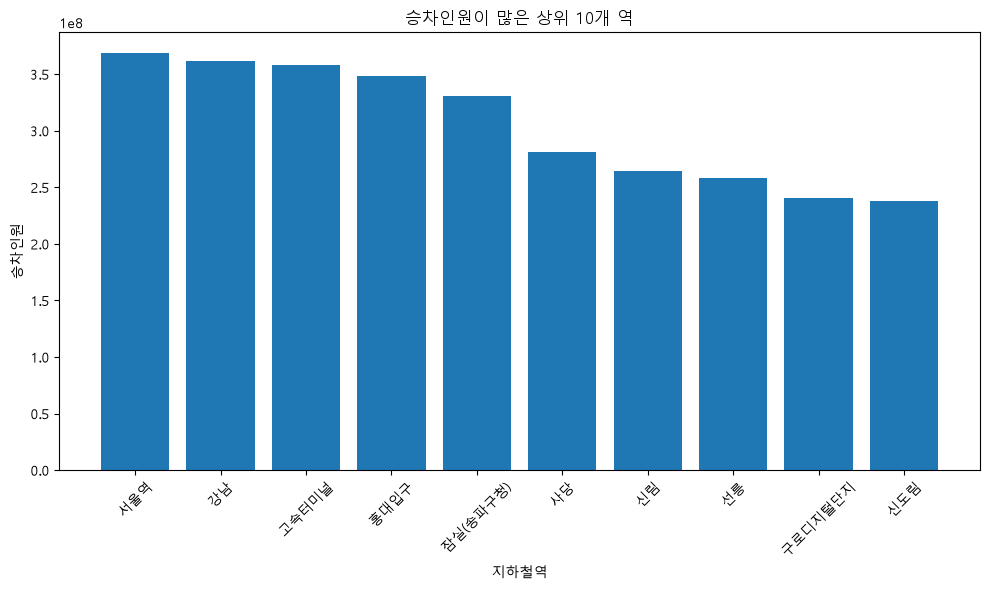

In [40]:
# 승차인원이 많은 상위 10개 역 그래프 시각화
top10 = station_total.head(10)

plt.figure(figsize=(10, 6))
plt.bar(top10.index, top10.values)
plt.title("승차인원이 많은 상위 10개 역")
plt.xlabel("지하철역")
plt.ylabel("승차인원")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [41]:
# 월별 전체 승차인원 추이
monthly_sum = df.groupby("사용월")[boarding_cols].sum()
monthly_total = monthly_sum.sum(axis=1)
monthly_total = monthly_total.sort_index()
monthly_total.head()

사용월
201501    218639396
201502    188391561
201503    239270675
201504    236022558
201505    234296965
dtype: int64

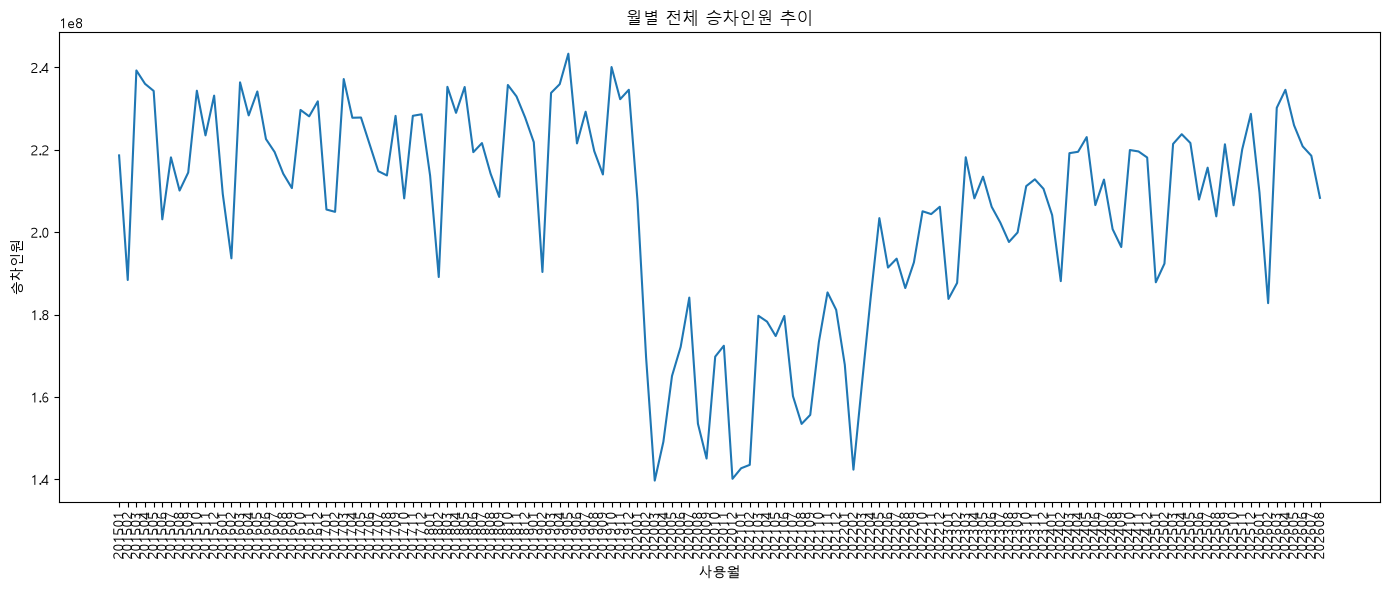

In [42]:
# 월별 승차인원 그래프 시각화
plt.figure(figsize=(14, 6))
plt.plot(monthly_total.index.astype(str), monthly_total.values)
plt.title("월별 전체 승차인원 추이")
plt.xlabel("사용월")
plt.ylabel("승차인원")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [43]:
# 특정 역(강남)의 시간대별 평균 승차인원
station_data = df[df["지하철역"] == "강남"]
station_avg = station_data[boarding_cols].mean()
station_avg

04시-05시 승차인원       210.228571
05시-06시 승차인원     11875.057143
06시-07시 승차인원     21295.250000
07시-08시 승차인원     43379.207143
08시-09시 승차인원     68726.971429
09시-10시 승차인원     58241.400000
10시-11시 승차인원     58374.685714
11시-12시 승차인원     77678.107143
12시-13시 승차인원     98078.035714
13시-14시 승차인원    122971.285714
14시-15시 승차인원    129223.550000
15시-16시 승차인원    155560.857143
16시-17시 승차인원    178779.514286
17시-18시 승차인원    246318.335714
18시-19시 승차인원    344396.164286
19시-20시 승차인원    234304.278571
20시-21시 승차인원    186215.821429
21시-22시 승차인원    222176.978571
22시-23시 승차인원    216376.771429
23시-24시 승차인원     93874.664286
00시-01시 승차인원     15183.328571
01시-02시 승차인원        46.042857
02시-03시 승차인원         5.428571
03시-04시 승차인원         0.300000
dtype: float64

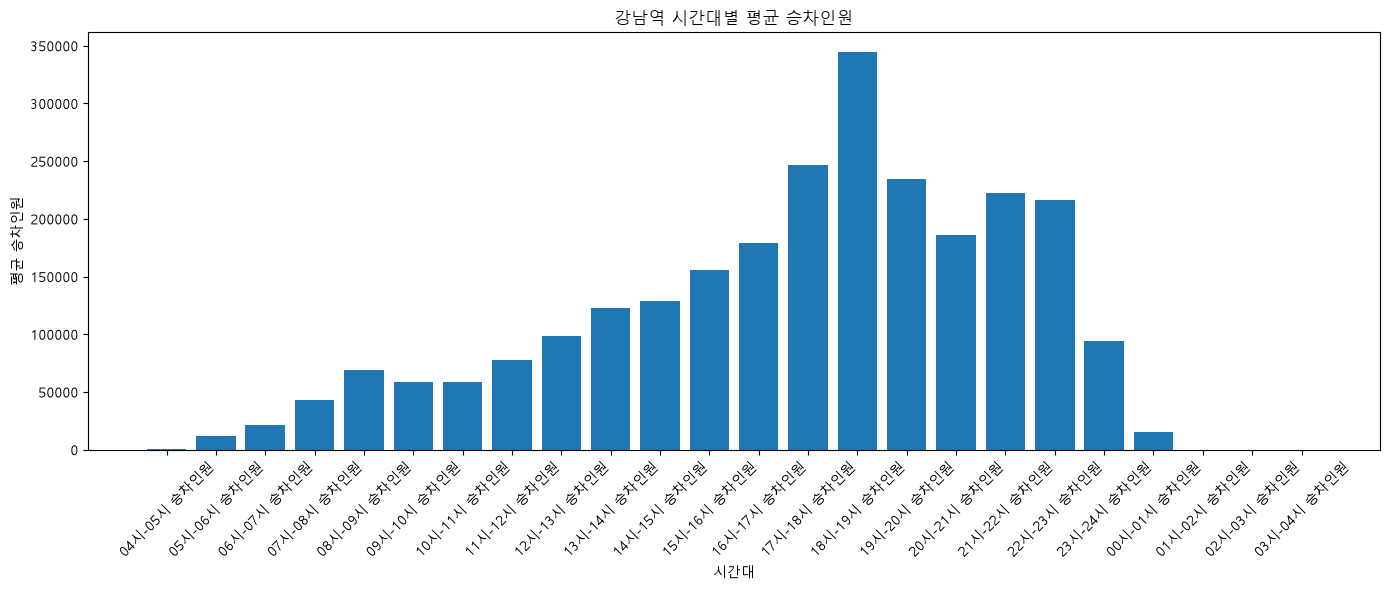

In [44]:
# 강남역 시간대별 그래프
plt.figure(figsize=(14, 6))
plt.bar(station_avg.index, station_avg.values)
plt.title("강남역 시간대별 평균 승차인원")
plt.xlabel("시간대")
plt.ylabel("평균 승차인원")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 6. 전처리 — 원본 데이터 → 머신러닝용 형태로 변환

In [54]:
# wide -> long 형태로 변환 (시간대 컬럼들을 하나의 컬럼으로)
df_long = df.melt(
    id_vars=["사용월", "호선명", "지하철역"],
    value_vars=boarding_cols,
    var_name="시간대",
    value_name="승차인원"
)
print(df_long.head())
print()

df_long["시간대"] = df_long["시간대"].str.replace(" 승차인원", "", regex=False)
print(df_long.head())
print()

df_long["사용월"] = df_long["사용월"].astype(str)
df_long["연도"] = df_long["사용월"].str[:4].astype(int)
df_long["월"] = df_long["사용월"].str[4:6].astype(int)
print(df_long.head())
print()

df_ml = df_long[["연도", "월", "호선명", "지하철역", "시간대", "승차인원"]]
print(df_long.head())
print()

      사용월  호선명 지하철역           시간대  승차인원
0  202608  1호선  동대문  04시-05시 승차인원   378
1  202608  1호선  동묘앞  04시-05시 승차인원   131
2  202608  1호선  서울역  04시-05시 승차인원   721
3  202608  1호선   시청  04시-05시 승차인원    43
4  202608  1호선  신설동  04시-05시 승차인원   285

      사용월  호선명 지하철역      시간대  승차인원
0  202608  1호선  동대문  04시-05시   378
1  202608  1호선  동묘앞  04시-05시   131
2  202608  1호선  서울역  04시-05시   721
3  202608  1호선   시청  04시-05시    43
4  202608  1호선  신설동  04시-05시   285

      사용월  호선명 지하철역      시간대  승차인원    연도  월
0  202608  1호선  동대문  04시-05시   378  2026  8
1  202608  1호선  동묘앞  04시-05시   131  2026  8
2  202608  1호선  서울역  04시-05시   721  2026  8
3  202608  1호선   시청  04시-05시    43  2026  8
4  202608  1호선  신설동  04시-05시   285  2026  8

      사용월  호선명 지하철역      시간대  승차인원    연도  월
0  202608  1호선  동대문  04시-05시   378  2026  8
1  202608  1호선  동묘앞  04시-05시   131  2026  8
2  202608  1호선  서울역  04시-05시   721  2026  8
3  202608  1호선   시청  04시-05시    43  2026  8
4  202608  1호선  신설동  04시-05시   285  2026  8



## 7. 학습/테스트 데이터 준비 (정렬 → 인코딩 → 분할)

In [58]:
from scipy import sparse

# 데이터를 월 기준으로 정렬 (시계열 순서를 지키기 위해)
df_ml = df_ml.sort_values(["연도", "월"]).reset_index(drop=True)

X = df_ml[["연도", "월", "호선명", "지하철역", "시간대"]]
y = df_ml["승차인원"]

# 문자열로 되어 있는 범주형 컬럼
categorical_cols = ["호선명", "지하철역", "시간대"]

# sparse_output=True (기본값) 로 -> 희소행렬로 반환
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
X_categorical = encoder.fit_transform(X[categorical_cols])

# 연도, 월도 sparse로 바꿔서 합치기 (np.column_stack 대신 sparse.hstack 사용)
X_numeric = sparse.csr_matrix(X[["연도", "월"]].values)
X_encoded = sparse.hstack([X_numeric, X_categorical]).tocsr()

print("최종 X 크기:", X_encoded.shape)
print("y 크기:", y.shape)

최종 X 크기: (2006328, 655)
y 크기: (2006328,)


In [61]:
# 80%를 학습 데이터로, 20%를 테스트 데이터로 사용 (시간 순서 유지)
split_index = int(X_encoded.shape[0] * 0.8)

X_train = X_encoded[:split_index]
X_test = X_encoded[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (1605062, 655)
X_test: (401266, 655)
y_train: (1605062,)
y_test: (401266,)


## 8. 모델 학습 (RandomForestRegressor)

In [66]:
model = RandomForestRegressor(
    n_estimators=30,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)

MAE : 8344.647664183793
RMSE: 13580.553236596763
R2  : 0.632104974911117


## 9. 모델 저장

In [67]:
import joblib
import os

# model 폴더 없으면 만들기
os.makedirs("model", exist_ok=True)

# 학습된 모델 저장
joblib.dump(model, "model/subway_model.pkl")

# 인코더 저장 (Streamlit에서 입력값을 학습 때와 똑같이 변환하려면 필수)
joblib.dump(encoder, "model/subway_encoder.pkl")

# 셀렉트박스에 넣을 실제 값 목록도 같이 저장
joblib.dump({
    "호선명_목록": sorted(df_ml["호선명"].unique().tolist()),
    "지하철역_목록": sorted(df_ml["지하철역"].unique().tolist()),
    "시간대_목록": sorted(df_ml["시간대"].unique().tolist()),
    "연도_범위": (int(df_ml["연도"].min()), int(df_ml["연도"].max())),
}, "model/subway_options.pkl")

print("모델 저장 완료: model/subway_model.pkl")
print("인코더 저장 완료: model/subway_encoder.pkl")
print("옵션 목록 저장 완료: model/subway_options.pkl")

모델 저장 완료: model/subway_model.pkl
인코더 저장 완료: model/subway_encoder.pkl
옵션 목록 저장 완료: model/subway_options.pkl
